In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

loadfile = 'sst_OISST.npz'
sst_dataset = np.load(loadfile) #load函数用来读取文件里面的数组数据
# .npz保存多个数组数据的压缩包

sst_dataset.files #确定里面的内容
#里面存了5个数组['sst', 'lon2', 'lat2', 'y', 'm']

sst = sst_dataset['sst'] #海面水温
lon2 = sst_dataset['lon2'] #经度，2是二维数组
lat2 = sst_dataset['lat2'] #纬度
y = sst_dataset['y'] #年份
m = sst_dataset['m'] #月

%whos 
#书上没有带%，因为开启了automagic，为了不发生冲突以后都带上%
#可以展示数据类型等信息

lon2 # 经度

lat2 # 纬度

y # 年

m # 月

sst[:, :, 0] #1982年1月的日期是最开始，所以是第0个
#输出里面有nan，代表未定义值，因为只有海上气温，所以陆地上都是未确定值
#第一个：代表所有的经度，第二个：代表所有的纬度，后面的0代表第0个数据




Variable      Type       Data/Info
----------------------------------
Normalize     ABCMeta    <class 'matplotlib.colors.Normalize'>
lat2          ndarray    360x180: 64800 elems, type `float64`, 518400 bytes (506.25 kb)
loadfile      str        sst_OISST.npz
lon2          ndarray    360x180: 64800 elems, type `float64`, 518400 bytes (506.25 kb)
m             ndarray    456: 456 elems, type `float64`, 3648 bytes
np            module     <module 'numpy' from 'D:\<...>ges\\numpy\\__init__.py'>
plt           module     <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sst           ndarray    360x180x456: 29548800 elems, type `float64`, 236390400 bytes (225.439453125 Mb)
sst_dataset   NpzFile    NpzFile 'sst_OISST.npz' w<...>ys: sst, lon2, lat2, y, m
y             ndarray    456: 456 elems, type `float64`, 3648 bytes


array([[-1.78999996, -1.78999996, -1.77999997, ...,         nan,
                nan,         nan],
       [-1.78999996, -1.78999996, -1.77999997, ...,         nan,
                nan,         nan],
       [-1.78999996, -1.78999996, -1.77999997, ...,         nan,
                nan,         nan],
       ...,
       [-1.78999996, -1.78999996, -1.78999996, ...,         nan,
                nan,         nan],
       [-1.78999996, -1.78999996, -1.78999996, ...,         nan,
                nan,         nan],
       [-1.78999996, -1.78999996, -1.78999996, ...,         nan,
                nan,         nan]], shape=(360, 180))

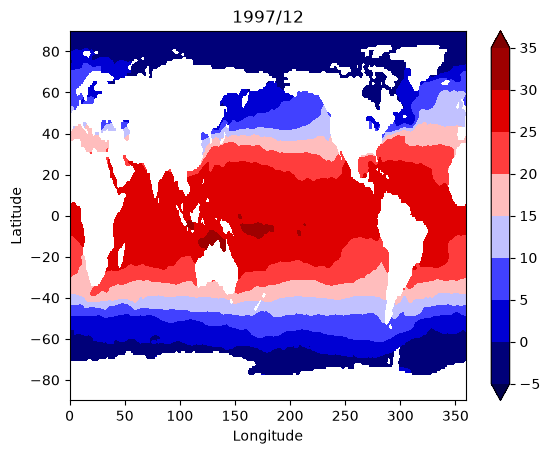

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

loadfile = 'sst_OISST.npz'
sst_dataset = np.load(loadfile) #load函数用来读取文件里面的数组数据
# .npz保存多个数组数据的压缩包

sst_dataset.files #确定里面的内容
#里面存了5个数组['sst', 'lon2', 'lat2', 'y', 'm']

sst = sst_dataset['sst'] #海面水温
lon2 = sst_dataset['lon2'] #经度，2是二维数组
lat2 = sst_dataset['lat2'] #纬度
y = sst_dataset['y'] #年份
m = sst_dataset['m'] #月

# 定义想画的年份和月数
draw_year = 1997
draw_month = 12

# 定义色条的下限和上限，以及色条之间的间隔
vmin = -5
vmax = 35
vint = 5

# 指定从深青到深红的色带
cm = plt.get_cmap('seismic')

# 绘制涂色的等高线
#contourf是填充并绘制等高线
#此处的*是逻辑与，squeeze是强制变成二维平面
#vmin=vmin, vmax=vmax强制对齐规定最下限和最上限
#从vmin开始到vmin+vmax为止，间隔为vint
#extend='both'是超出范围的极端数据，用箭头去表示
cs = plt.contourf(lon2, lat2, \
                  np.squeeze(sst[:, :, (y==draw_year)*(m==draw_month)]), \
                  cmap=cm, norm=Normalize(vmin=vmin, vmax=vmax), \
                  levels=np.arange(vmin,vmax+vint,vint), extend='both')

plt.colorbar(cs)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(0, 360)
plt.ylim(-90, 90)

title = str(draw_year) + '/' + str(draw_month) #数字拼成文本
plt.title(title)

plt.show()